# 03. 분류 모델 — 관측 종료 시점의 생존 예측

관측 종료 시점 기준으로 묘목이 **생존했는가(1) / 사망했는가(0)** 를 예측한다.

### 이 노트북의 핵심 질문
> "높은 정확도가 항상 좋은 모델을 뜻할까?"

`01_EDA`에서 `Time`이 결과를 그대로 담은 누수 컬럼임을 확인했다. 여기서는
1. **누수를 제거한 정직한 성능**을 세 모델로 측정하고,
2. **누수(Time)를 넣으면 성능이 어떻게 부풀려지는지** 대비해서 보여준다.

이것이 이 프로젝트를 복기하며 가장 강조하고 싶은 지점이다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
import platform

if platform.system() == "Windows":
    rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    rcParams["font.family"] = "AppleGothic"
rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font=rcParams["font.family"])

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, RocCurveDisplay)
import xgboost as xgb

RANDOM_STATE = 42

In [2]:
clf = pd.read_csv("../data/processed/clf_dataset.csv")
X = clf.drop(columns="Survived")
y = clf["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"train {X_train.shape}, test {X_test.shape}")
print(f"피처 {list(X.columns)}")
print(f"전체 생존율 {y.mean():.3f}")

train (1662, 13), test (416, 13)
피처 ['Species', 'Light_ISF', 'Light_Cat', 'Soil', 'Sterile', 'Conspecific', 'Myco', 'SoilMyco', 'AMF', 'EMF', 'Phenolics', 'Lignin', 'NSC']
전체 생존율 0.236


## 1. 세 모델 비교 (누수 제거 버전)

- **Logistic Regression** — 선형 기준선 (스케일링 포함)
- **Random Forest** — 트리 앙상블
- **XGBoost** — 부스팅

동일한 train/test로 공정 비교한다.

In [3]:
def evaluate(name, model, needs_scaling=False):
    m = make_pipeline(StandardScaler(), model) if needs_scaling else model
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba),
        "_fitted": m,
        "_proba": proba,
        "_pred": pred,
    }

results = [
    evaluate("Logistic", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
             needs_scaling=True),
    evaluate("RandomForest", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)),
    evaluate("XGBoost", xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                                          eval_metric="logloss", random_state=RANDOM_STATE)),
]

score_df = pd.DataFrame(results)[["model", "accuracy", "f1", "roc_auc"]].set_index("model")
score_df.round(4)

,accuracy,f1,roc_auc
model,,,
Logistic,0.8486,0.7296,0.8938
RandomForest,0.8269,0.6250,0.9002
XGBoost,0.8149,0.5926,0.8954


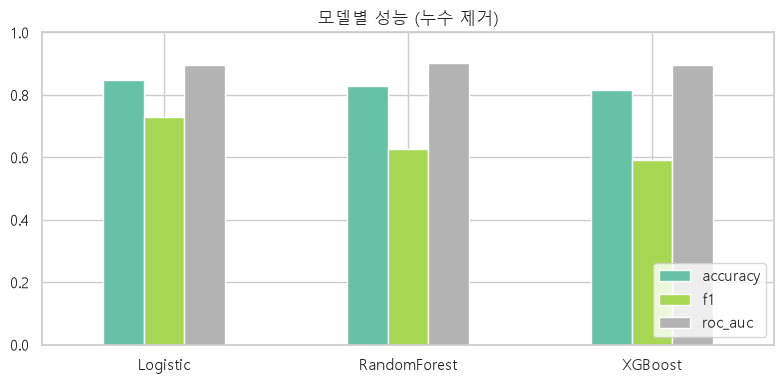

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
score_df.plot(kind="bar", ax=ax, colormap="Set2")
ax.set_title("모델별 성능 (누수 제거)")
ax.set_ylim(0, 1)
ax.set_xlabel("")
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

세 모델 모두 정확도 0.81~0.85, ROC-AUC 0.89~0.90 수준이다.

흥미롭게도 **Logistic이 가장 좋다.** `01_EDA`에서 봤듯 균근 타입(`Myco`)과 수종(`Species`) 신호가 워낙 명확해서, 복잡한 트리 모델이 아니어도 선형 경계로 충분히 잘 잡힌다는 뜻이다.

## 2. ROC 곡선 & 혼동 행렬

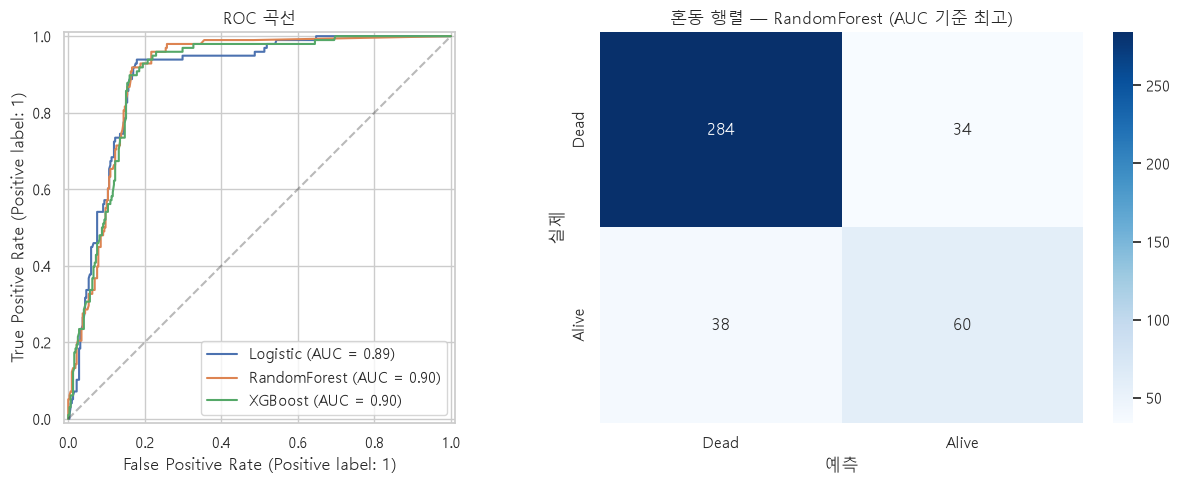

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
for r in results:
    RocCurveDisplay.from_predictions(y_test, r["_proba"], name=r["model"], ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_title("ROC 곡선")

# 최고 모델 혼동행렬
best = max(results, key=lambda r: r["roc_auc"])
cm = confusion_matrix(y_test, best["_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Dead", "Alive"], yticklabels=["Dead", "Alive"])
axes[1].set_title(f"혼동 행렬 — {best['model']} (AUC 기준 최고)")
axes[1].set_xlabel("예측")
axes[1].set_ylabel("실제")
plt.tight_layout()
plt.show()

## 3. 어떤 피처가 중요한가

트리 모델(RandomForest)의 피처 중요도를 본다.

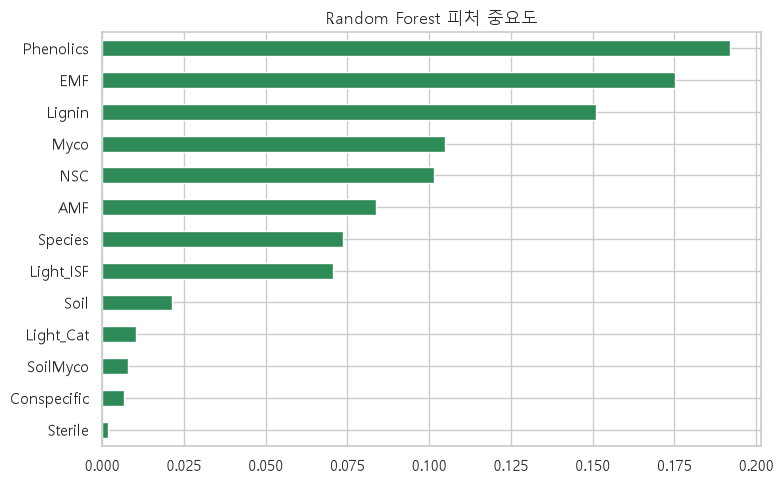

Phenolics      0.1918
EMF            0.1752
Lignin         0.1509
Myco           0.1047
NSC            0.1015
AMF            0.0838
Species        0.0735
Light_ISF      0.0706
Soil           0.0214
Light_Cat      0.0104
SoilMyco       0.0078
Conspecific    0.0067
Sterile        0.0017


In [6]:
rf = [r for r in results if r["model"] == "RandomForest"][0]["_fitted"]
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
imp.plot(kind="barh", ax=ax, color="seagreen")
ax.set_title("Random Forest 피처 중요도")
plt.tight_layout()
plt.show()

print(imp.sort_values(ascending=False).round(4).to_string())

EDA에서 예상한 대로 **`Myco`(균근 타입), `Species`(수종), 화학 성분(`Phenolics` 등)** 이 상위를 차지한다. 실제 생물학적으로 의미 있는 요인들이 예측을 이끈다 — 누수 없이 얻은 정직한 결과다.

## 4. 대조 실험: 누수 컬럼(`Time`)을 넣으면?

이제 일부러 `Time`을 피처에 추가해서, 누수가 성능을 어떻게 부풀리는지 확인한다.

In [7]:
# 원본에서 Time을 가져와 같은 인덱스로 정렬해 붙인다
raw = pd.read_csv("../data/raw/Tree_Data.csv")
d = raw.copy()
d["Status"] = np.nan
d.loc[d["Event"] == 1, "Status"] = 0
d.loc[d["Harvest"] == "X", "Status"] = 1
d.loc[d["Alive"] == "X", "Status"] = 2
d = d.dropna(subset=["Status"])
d = d[d["Status"].isin([0, 2])]

X_leak = X.copy()
X_leak["Time"] = d["Time"].values   # 누수 컬럼 추가

Xtr_l, Xte_l, ytr_l, yte_l = train_test_split(
    X_leak, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
leak_model = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
leak_model.fit(Xtr_l, ytr_l)
p = leak_model.predict(Xte_l)
pr = leak_model.predict_proba(Xte_l)[:, 1]
print(f"RF + Time(누수):  acc={accuracy_score(yte_l,p):.4f}  "
      f"f1={f1_score(yte_l,p):.4f}  auc={roc_auc_score(yte_l,pr):.4f}")

RF + Time(누수):  acc=0.9976  f1=0.9949  auc=1.0000


In [8]:
rf_clean = [r for r in results if r["model"] == "RandomForest"][0]
compare = pd.DataFrame({
    "누수 제거 (RF)": [rf_clean["accuracy"], rf_clean["f1"], rf_clean["roc_auc"]],
    "누수 포함 (RF+Time)": [accuracy_score(yte_l, p), f1_score(yte_l, p), roc_auc_score(yte_l, pr)],
}, index=["accuracy", "f1", "roc_auc"]).round(4)
compare

,누수 제거 (RF),누수 포함 (RF+Time)
accuracy,0.8269,0.9976
f1,0.6250,0.9949
roc_auc,0.9002,1.0000


**`Time` 하나를 넣자 ROC-AUC가 0.90 → 1.00, 정확도 0.83 → 0.998로 뛴다.**

거의 완벽해 보이지만, 이 모델은 실제로는 쓸모가 없다. `Time`은 예측 시점에 알 수 없는 값(결과가 나야 정해짐)이기 때문이다. 새 묘목을 심는 순간에는 그 묘목이 언제 죽을지/끝까지 살지 알 수 없다.

> **핵심 교훈**: 높은 성능 지표가 항상 좋은 모델을 뜻하지 않는다. 그 수치가 *예측 시점에 실제로 알 수 있는 정보*로 만들어진 것인지 반드시 확인해야 한다.

## 5. 분류의 한계

정직하게 만든 분류 모델도 한계가 있다.
- **관측 종료 시점(115.5일) 한 순간의 생존/사망**만 예측한다.
- 하지만 실무에서는 "이 묘목이 *언제쯤* 위험해지는가", "30일 뒤 생존 확률은?" 같은 **시간에 따른** 질문이 더 유용하다.
- 또한 수확된 개체(704그루)를 그냥 버렸는데, 이들도 "그 시점까지 살아있었다"는 정보를 담고 있다.

이 한계를 다루기 위해 다음 노트북(`04_survival_analysis`)에서 **생존 분석(Survival Analysis)** 으로 넘어간다.